# Conv1D input layer


- Sliding Window Data 생성

- Conv1D + LSTM model 작성

- Learning Rate Tunning

- Window Size Tuning

### Sunspots 데이터셋을 활용하여 window_dataset 만들기

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
np.random.seed(42)
tf.random.set_seed(51)

url = 'https://storage.googleapis.com/download.tensorflow.org/data/Sunspots.csv'
df = pd.read_csv(url, skiprows=0, index_col=0)   #첫 줄은 header이므로 skip
df.shape

(3235, 2)

In [2]:
df.head()

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7


Data 시각화

3235


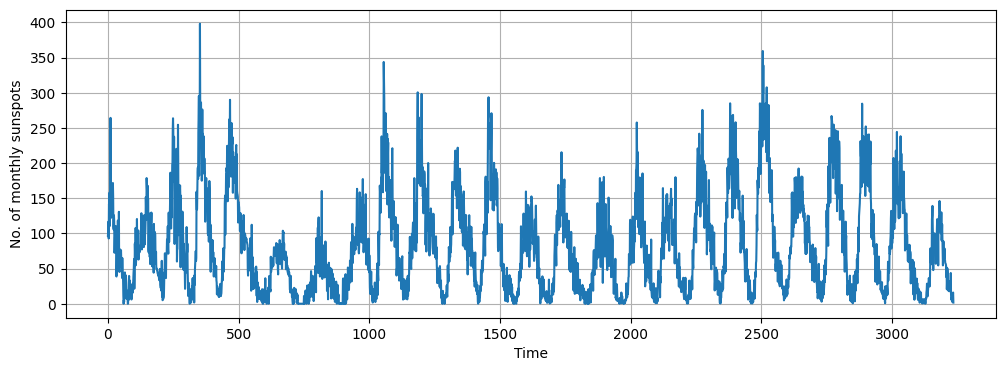

In [3]:
# 'Monthly Mean Total Sunspot Number' 컬럼을 numpy 배열로 추출
series = df['Monthly Mean Total Sunspot Number'].values
time = range(series.size)  # 시간 인덱스 생성 (0 ~ 데이터 크기-1)
print(series.size)         # 전체 데이터 크기 출력

# 전체 시계열 데이터 시각화
plt.figure(figsize=(12, 4))
plt.plot(time, series)
plt.xlabel("Time")
plt.ylabel("No. of monthly sunspots")  # 월별 흑점 수
plt.grid(True)

- 시간 절약을 위해 최근 1000 개월치 data 만 이용

In [4]:
time = df.iloc[-1000:, 0].values
time_series = df.iloc[-1000:, 1].values
time.shape, time_series.shape

((1000,), (1000,))

### windowed dataset 생성

1. series를 이용해 tf.data.Dataset.from_tensor_slices로 데이터셋을 생성합니다.  
2. ds.window를 사용하여 입력 데이터셋을 지정한 윈도우 크기와 함께 슬라이딩 윈도우 방식으로 나눕니다.   drop_remainder=True는 윈도우 크기보다 작은 마지막 윈도우를 제거합니다.  
3. ds.flat_map을 사용하여 각 윈도우를 하나의 배치로 펼칩니다.  
4. ds.shuffle을 사용하여 데이터셋을 무작위로 섞습니다. 이렇게 하면 모델이 훈련 데이터의 순서를 기억하는 것을 방지할 수 있습니다.  
5. ds.map에서 입력 데이터의 마지막 원소를 제외한 부분을 X로 사용하고, 첫 원소를 제외한 부분을 y로 사용하여 다중 스텝 출력을 준비합니다.  
6. 마지막으로, ds.batch를 사용하여 지정된 배치 크기로 데이터를 나누고, ds.prefetch를 사용하여 효율적인 학습을 위해 데이터를 미리 가져옵니다.

**이전 버전과의 차이점:**
```
w[:-1], w[-1]  → 마지막 단일 값 예측
w[:-1], w[1:]  → 다음 시퀀스 전체 예측 (multi-step)
```

In [5]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    # 시계열 데이터를 TensorFlow Dataset으로 변환
    ds = tf.data.Dataset.from_tensor_slices(series)

    # 슬라이딩 윈도우 적용 (window_size+1 : 입력 + 정답 시퀀스 포함, 크기 미달 윈도우 제거)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)

    # 중첩 Dataset을 1D 텐서로 변환
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))

    # 셔플 후 입력(X)과 정답(y) 분리 - multi-step output (many-to-many)
    # w[:-1] : 앞 window_size개 → 입력 시퀀스 (X)
    # w[1:]  : 뒤 window_size개 → 정답 시퀀스 (y) ← 한 칸씩 뒤로 이동
    ds = ds.shuffle(shuffle_buffer).map(lambda w: (w[:-1], w[1:]))

    # 미니배치 구성 및 다음 배치 미리 준비 (학습 속도 향상)
    ds = ds.batch(batch_size).prefetch(1)
    return ds

#### Forecast Helper Function

- training 후 series data를 model 입력 사양에 맞추어 예측하기 위해 사용 (batch, shuffle 제외)  
- 지도학습 label 불필요하므로 window size 에 +1 을 해줄 필요 없습니다.

**`windowed_dataset` vs `model_forecast` 비교:**
```
windowed_dataset  (학습용)          model_forecast  (예측용)
window_size + 1  ← 정답 포함       window_size     ← 입력만 (정답 불필요)
map(X, y 분리)   ← 정답 생성        map 없음        ← X만 생성
shuffle 있음     ← 순서 섞기        shuffle 없음    ← 순서 유지 필수
batch(batch_size)                  batch(1)        ← 한 번에 1개씩 예측
```

In [6]:
def model_forecast(model, series, window_size):
    # 시계열 데이터를 TensorFlow Dataset으로 변환
    ds = tf.data.Dataset.from_tensor_slices(series)

    # 슬라이딩 윈도우 적용 (예측용이므로 정답 불필요 → window_size만큼만 슬라이싱)
    ds = ds.window(window_size, shift=1, drop_remainder=True)

    # 중첩 Dataset을 1D 텐서로 변환
    ds = ds.flat_map(lambda w: w.batch(window_size))

    # 배치 크기=1로 묶고 다음 배치 미리 준비
    ds = ds.batch(1).prefetch(1)

    # 모델로 예측 수행
    forecast = model.predict(ds)
    return forecast

### train/validation set 분리

In [7]:
# 학습/테스트 데이터 분리 기준점 설정 (700번째 시점 기준)
split_time = 700

# 시간 인덱스 분리
time_train = time[:split_time]   # 학습 구간 시간 인덱스
time_test  = time[split_time:]   # 테스트 구간 시간 인덱스

# 시계열 값 분리
X_train = time_series[:split_time]  # 학습 데이터
X_test  = time_series[split_time:]  # 테스트 데이터

# 정규화: 신경망은 0~1 범위의 입력에서 훨씬 잘 학습함
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1)).flatten()
X_test_scaled  = scaler.transform(X_test.reshape(-1, 1)).flatten()
time_series_scaled = np.concatenate([X_train_scaled, X_test_scaled])

# 각 데이터 크기 확인
len(time_train), len(time_test), len(X_train), len(X_test)

(700, 300, 700, 300)

In [8]:
window_size = 132  #132, 64, 30
batch_size = 64
shuffle_buffer_size = 1000

# 정규화된 학습 데이터로 windowed dataset 생성
train_ds = windowed_dataset(X_train_scaled, window_size, batch_size, shuffle_buffer_size)
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.float64, name=None), TensorSpec(shape=(None, None), dtype=tf.float64, name=None))>

## Conv1D + LSTM + Bidirectional

- Causal Convolution(인과관계 컨벌루션)은 시간 t의 출력이 시간 t - 1의 입력에서만 파생되도록 합니다.

- Causal padding 은 `Conv1D`에만 지원됩니다.

<img src="https://user-images.githubusercontent.com/24662250/29258799-9b3ff514-80f7-11e7-83e4-ab701fdc2720.png" width=500 />

Causal Convolution(인과 관계 컨벌루션)은 시계열 데이터를 처리할 때 사용되는 기법입니다. 시간 t의 출력이 시간 t 이전의 데이터로만 생성되기 때문에 인과 관계를 유지할 수 있습니다. 이 방법은 미래 데이터를 참조하지 않고 현재 및 과거 데이터만 사용하여 미래를 예측할 수 있게 합니다.

Causal padding은 인과 관계 컨벌루션을 구현하기 위한 패딩 기법입니다. 일반적인 컨벌루션과 달리, causal padding은 입력의 오른쪽 끝(또는 시계열 데이터의 미래 부분)에는 패딩을 추가하지 않고 입력의 왼쪽 끝(또는 시계열 데이터의 과거 부분)에만 패딩을 추가합니다. 이로 인해 컨볼루션 필터는 현재 및 과거 값에만 접근할 수 있으며, 미래 데이터는 참조하지 않게 됩니다.

TensorFlow에서는 Conv1D 레이어를 사용하여 인과 관계 컨벌루션을 구현할 수 있습니다. 이를 위해 padding='causal' 인자를 사용하면 됩니다.

In [23]:
def model_define(kernel_size):
    model = tf.keras.models.Sequential([
      tf.keras.layers.Input(shape=[None, 1]),
      tf.keras.layers.Conv1D(filters=32, kernel_size=kernel_size, strides=1, padding="causal",
                             activation="relu"),
      # 참고: Bidirectional은 윈도우 내 양방향 패턴을 캡처하는 데 효과적이나,
      # 엄밀한 인과성(causality)이 필요한 경우 단방향 LSTM을 고려할 것
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),
      tf.keras.layers.Dense(1),
    ])
    return model

- 초기 epoch 100 동안 learning rate를 변경해 가며 loss가  증가하지 않는 가장 큰 learning rate 를 찾아냅니다.

**학습률 스케줄러 동작 방식:**
```
epoch  0 : 1e-8 * 10^(0/20)  = 1e-8
epoch 20 : 1e-8 * 10^(20/20) = 1e-7
epoch 40 : 1e-8 * 10^(40/20) = 1e-6
epoch 60 : 1e-8 * 10^(60/20) = 1e-5
epoch 80 : 1e-8 * 10^(80/20) = 1e-4
epoch 100: 1e-8 * 10^(100/20)= 1e-3
```

In [24]:
# 커널 크기=5로 Conv1D + Bidirectional LSTM 모델 생성
model = model_define(kernel_size=5)

# 최적 학습률 탐색을 위한 학습률 스케줄러 정의
# epoch 증가에 따라 학습률을 1e-8 → 1e-8 * 10^5 까지 점진적으로 증가
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20)
)

# SGD 옵티마이저 설정 (초기 학습률=1e-8, momentum=0.9)
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-8, momentum=0.9)

# 모델 컴파일
model.compile(
    loss=tf.keras.losses.Huber(),  # Huber 손실함수: 이상치에 강건한 MSE+MAE 혼합
    optimizer=optimizer,
    metrics=["mae"]                # 평가지표: 평균 절대 오차
)

# 모델 학습 (학습률 스케줄러 적용)
history = model.fit(train_ds, epochs=100, verbose=1, callbacks=[lr_schedule])

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0827 - mae: 0.3290 - learning_rate: 1.0000e-08
Epoch 2/100
1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.0777 - mae: 0.3207

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0815 - mae: 0.3271 - learning_rate: 1.1220e-08
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0813 - mae: 0.3270 - learning_rate: 1.2589e-08
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0810 - mae: 0.3269 - learning_rate: 1.4125e-08
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0804 - mae: 0.3258 - learning_rate: 1.5849e-08
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0820 - mae: 0.3284 - learning_rate: 1.7783e-08
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0830 - mae: 0.3296 - learning_rate: 1.9953e-08
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0820 - mae: 0.3277 - learning_rate: 2.2387e-08
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0828 - mae: 0.3297 - learning_rate: 2.5119e-08
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0811 - mae: 0.3267 - learning_rate: 2.8184e-08
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/st

- 안정적 상태에서 최소 mae 를 얻은 learning rate 선택

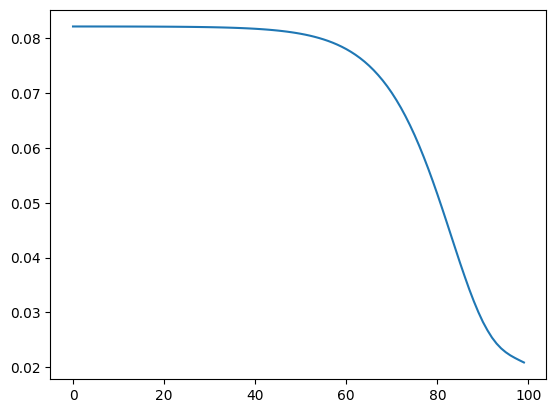

In [25]:
plt.plot(history.history["loss"])

(np.float64(1e-07), np.float64(0.001), np.float64(0.0), np.float64(0.1))

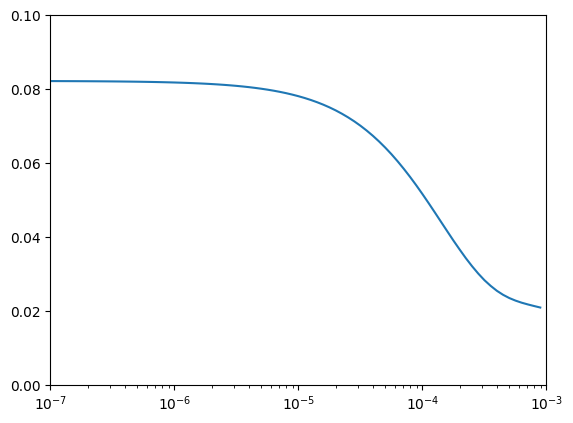

In [27]:
# x축을 로그 스케일로 학습률(lr)에 따른 손실(loss) 변화 시각화
plt.semilogx(history.history["learning_rate"], history.history["loss"])

# 축 범위 설정: x축 (학습률 범위), y축 (손실 범위)
plt.axis([1e-7, 1e-3, 0, 0.1])

그래프를 보면 loss가 약 10⁻⁵ 부근에서 가파르게 떨어지기 시작하므로, 최적 learning rate는 1e-5 ~ 5e-5 정도가 적절합니다

In [32]:
best_lr = 3e-5  # knee 지점 근처

### Hyper Parameter Tuning

- optimal learning rate로 충분한 epoch train   
    - optimal lr <-- best_lr  
    - epochs <-- 300

- kernel size를 3으로 조정

In [33]:
tf.keras.backend.clear_session()
EPOCHS = 300

# 정규화된 데이터로 학습/검증 데이터셋 생성
train_set = windowed_dataset(X_train_scaled, window_size, batch_size, shuffle_buffer_size)
val_set   = windowed_dataset(X_test_scaled, window_size, batch_size, shuffle_buffer_size)

model = model_define(kernel_size=3)

optimizer = tf.keras.optimizers.SGD(learning_rate=best_lr, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

# EarlyStopping: 검증 손실이 20 epoch 동안 개선되지 않으면 조기 종료
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

history = model.fit(train_set, epochs=EPOCHS, verbose=1,
                    validation_data=val_set, callbacks=[early_stop])

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0671 - mae: 0.2953 - val_loss: 0.0301 - val_mae: 0.1868
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0678 - mae: 0.2961 - val_loss: 0.0297 - val_mae: 0.1848
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0659 - mae: 0.2919 - val_loss: 0.0292 - val_mae: 0.1824
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0658 - mae: 0.2903 - val_loss: 0.0286 - val_mae: 0.1800
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0627 - mae: 0.2831 - val_loss: 0.0281 - val_mae: 0.1776
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0632 - mae: 0.2832 - val_loss: 0.0276 - val_mae: 0.1753
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0633 - mae: 0.2821 - val_loss: 0.0271 - val_mae: 0.1732
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0618 - mae: 0.2782 - val_loss: 0.0266 - val_mae: 0.1712
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0606 - mae:

훈련 과정에서 계산된 평균 절대 오차(MAE)와 손실 값(Loss)을 시각화 합니다.

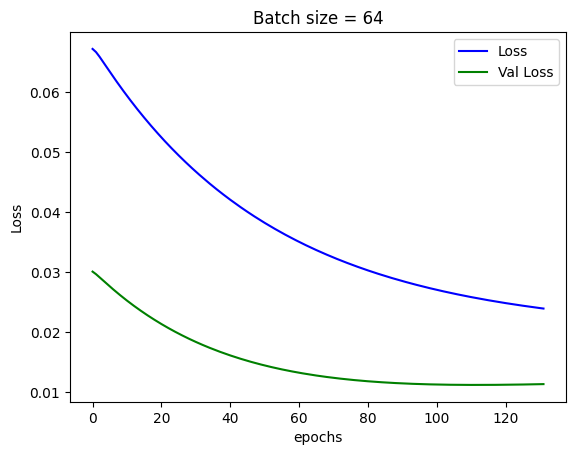

In [34]:
loss=history.history['loss']
val_loss=history.history['val_loss']

plt.plot(loss, 'b', label='Loss')
plt.plot(val_loss, 'g', label='Val Loss')
plt.title('Batch size = {}'.format(batch_size))
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()

In [35]:
print(time_series.shape)
print(X_test.shape)

(1000,)
(300,)


X_test data 를 이용하여 forecast

In [36]:
# 테스트 구간 예측을 위해 학습 데이터의 마지막 window_size 구간부터 포함 (정규화된 데이터 사용)
forecast = model_forecast(model, time_series_scaled[split_time - window_size:], window_size)
forecast.shape

301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


(301, 132, 1)

In [37]:
# 마지막 예측값은 ground truth가 없으므로 제거, 나머지는 X_test와 1:1 대응
forecast = forecast[:-1, -1, 0]

# 역정규화: 원본 스케일로 복원하여 실제값과 비교 가능하게 함
forecast = scaler.inverse_transform(forecast.reshape(-1, 1)).flatten()
forecast.shape

(300,)

### True value와 prediction value 비교 시각화

X_test(실제 값)와 forecast(예측 값)을 시계열 데이터로 시각화하는 코드입니다.

plt.plot() 함수를 사용하여 time_test와 X_test(실제 값)를 그래프로 그리고, 범례 레이블을 'True'로 설정합니다.  
plt.plot() 함수를 사용하여 time_test의 끝부분에서 예측된 값의 길이만큼과 forecast(예측 값)를 그래프로 그리고, 범례 레이블을 'Forecast'로 설정합니다.  

초반 window_size 만큼의 데이터는 예측 과정에서 skip되므로, 그래프에서도 그 부분이 생략되어 그려집니다.

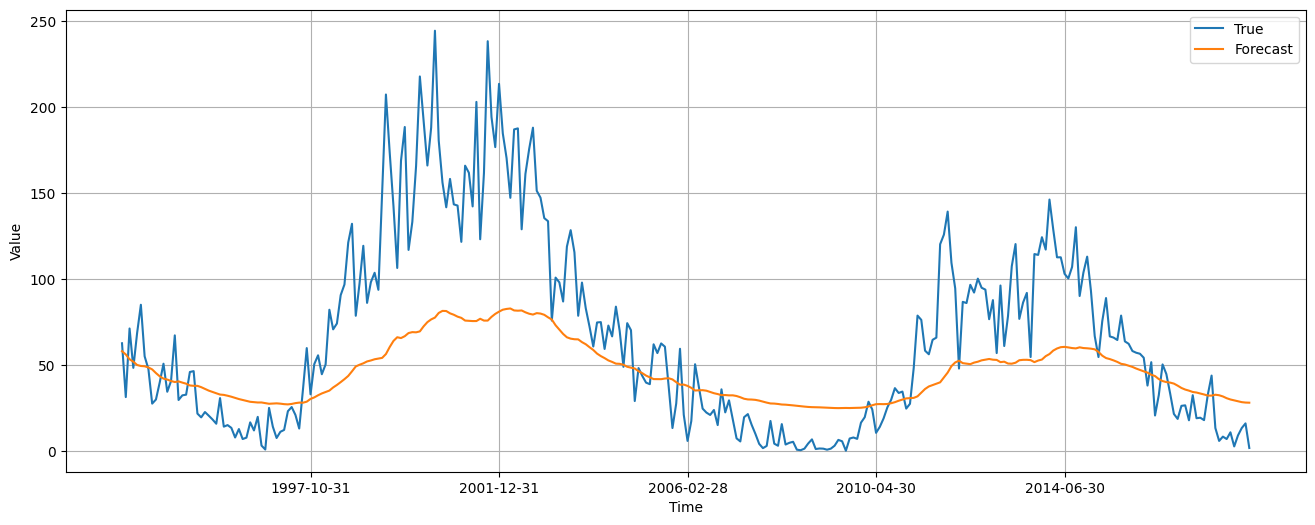

In [20]:
plt.figure(figsize=(16, 6))
plt.plot(time_test, X_test, label='True')
plt.plot(time_test, forecast, label='Forecast')
plt.xlabel("Time")
plt.ylabel("Value")
plt.xticks([50, 100, 150, 200, 250])
plt.grid(True)
plt.legend()

X_test와 forecast 간의 평균 제곱 오차(mean squared error, MSE)와 평균 절대 오차(mean absolute error, MAE)를 계산하고 출력합니다.

In [21]:
print(f"MSE: {mean_squared_error(X_test, forecast):.4f}")
print(f"MAE: {mean_absolute_error(X_test, forecast):.4f}")

MSE: 2118.9184
MAE: 33.0321


## Window Size를 바꾸어 가며 Tuning

11 년 주기의 noise 가 심한 data 이므로 다양한 size 의 window 를 try 하며 model tuning --> 132, 30, 64 등